In [1]:
from datascience import *
%matplotlib inline
path_data = '../../../assets/data/'
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
import numpy as np
import warnings
warnings.simplefilter(action='ignore', category=DeprecationWarning)

# Lecture 23 #

## Percentiles ##

The pth percentile is first value on the sorted list that is at least as large as p% of the elements.

If p% does not exactly correspond to an element, take the next greater element.

In [2]:
# Manually compute the 55th percentile of this array.

x = make_array(43, 20, 51, 7, 28, 34)

In [3]:
# Step 1. Sort the data into numerical order.

np.sort(x)

array([ 7, 20, 28, 34, 43, 51])

In [4]:
# Step 2. Figure out where 55th percentile would be.

np.arange(1, 7)/6

array([ 0.16666667,  0.33333333,  0.5       ,  0.66666667,  0.83333333,
        1.        ])

In [5]:
#Call the number that represents the value in the 55% percentile.

np.sort(x).item(3)

34

In [6]:
# Alternatively: One line of code

percentile(55, x)

34

### Discussion Question:

Which are True, when s = [1, 5, 7, 3, 9]?

* percentile(10, s) == 0 FALSE since 0 isn't an element of the array and we choose the next greater element

* percentile(39, s) == percentile(40, s) TRUE

* percentile(40, s) == percentile(41, s) FALSE we choose the next greater element for 41

* percentile(50, s) == 5 TRUE we choose the next greater element ( the original array is out of order, 3 comes before 5 so that is the 40th%



In [7]:
#Create your array.

s = make_array(1, 5, 7, 3, 9)

In [8]:
# Find the percentile for each value. Try using code instead of hard coding like above. 

np.arange(1, 6)/len(s)

array([ 0.2,  0.4,  0.6,  0.8,  1. ])

In [9]:
#Before running, what is your guess? Why?

percentile(10, s) == 0

False

In [10]:
#Before running, what is your guess? Why?

percentile(39, s) == percentile(40, s)

True

In [11]:
#Before running, what is your guess? Why?

percentile(40, s) == percentile(41, s)

False

In [12]:
#Before running, what is your guess? Why?

percentile(50, s) == 5

True

## Total Compensation in Population 

The table being imported is public data about the employees of the city and county of San Francisco in 2019. 
There are no personal identifiers, just information about each individual position. 

**Describe the table:** 


In [13]:
sf = Table.read_table('san_francisco_2019.csv')
sf.show(3)

Organization Group,Department,Job Family,Job,Salary,Overtime,Benefits,Total Compensation
Public Protection,Adult Probation,Information Systems,IS Trainer-Journey,91332,0,40059,131391
Public Protection,Adult Probation,Information Systems,IS Engineer-Assistant,123241,0,49279,172520
Public Protection,Adult Probation,Information Systems,IS Business Analyst-Senior,115715,0,46752,162468


In [14]:
# Find who made the most money

sf.where('Salary', np.max(sf.column('Salary')))

Organization Group,Department,Job Family,Job,Salary,Overtime,Benefits,Total Compensation
General Administration & Finance,Retirement Services,Administrative & Mgmt (Unrep),Chief Investment Officer,577633,0,146398,724031


In [15]:
# Find who made the least money

sf.where('Salary', np.min(sf.column('Salary')))

Organization Group,Department,Job Family,Job,Salary,Overtime,Benefits,Total Compensation
Public Protection,Juvenile Court,Correction & Detention,"Counselor, Log Cabin Rch PERS",-338,602,87,351


In [16]:
# Focus our research on employees who worked at least half time for the minimum wage of 2019
# for the full year, excluding two weeks for vacation.
# $15/hr, 20 hr/wk, 50 weeks

min_salary = 15 * 20 * 50

#Create a table that only shows employees who are above the minimum salary.

sf_min = sf.where('Salary', are.above(min_salary))
sf_min

Organization Group,Department,Job Family,Job,Salary,Overtime,Benefits,Total Compensation
Public Protection,Adult Probation,Information Systems,IS Trainer-Journey,91332,0,40059,131391
Public Protection,Adult Probation,Information Systems,IS Engineer-Assistant,123241,0,49279,172520
Public Protection,Adult Probation,Information Systems,IS Business Analyst-Senior,115715,0,46752,162468
Public Protection,Adult Probation,Information Systems,IS Business Analyst-Principal,159394,0,57312,216706
Public Protection,Adult Probation,Information Systems,IS Programmer Analyst,70035,0,28671,98706
Public Protection,Adult Probation,Information Systems,IS Project Director,175742,0,60830,236572
Public Protection,Adult Probation,Information Systems,IT Operations Support Admin IV,123840,0,49429,173269
Public Protection,Adult Probation,"Payroll, Billing & Accounting",Accountant III,111816,0,46319,158135
Public Protection,Adult Probation,"Budget, Admn & Stats Analysis",Statistician,87725,0,38899,126624
Public Protection,Adult Probation,"Budget, Admn & Stats Analysis",Senior Administrative Analyst,116192,0,47651,163843


In [17]:
# How many employees are left in our data with the restriction?

sf_min.num_rows


37103

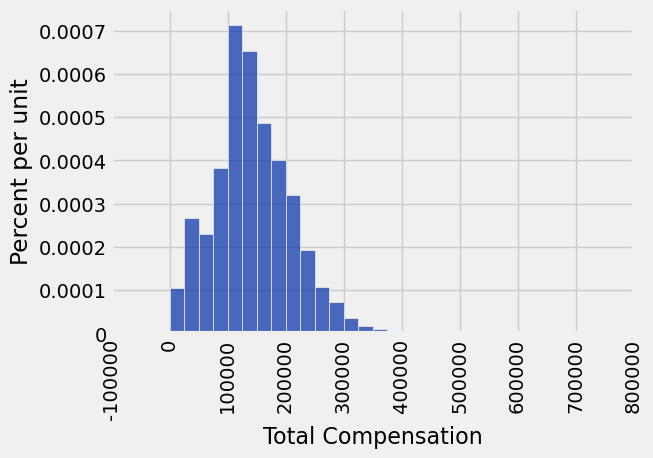

In [25]:
# Display a histogram of the cleaned up data using the given bins.

sf_bins = np.arange(0, 726000, 25000)

sf_min.hist('Total Compensation', bins=sf_bins)

#disregard the error that comes up. 

## Parameter: Median Total Compensation 

Median is a common measure used when talking about income because it is a middle value.

If we used the average (mean) value it would be affected by the employees with very large values and skew the appearance of incomes for the city/county jobs. 

What is the percentile of the median?

In [22]:
# Since we do have the entire population (restricted) we can get the population median. 

pop_median = percentile(50, sf_min.column('Total Compensation'))
pop_median

135747.0

## Estimating the Parameter (Pretend it is Unknown) 

If we did not have access to the entire population, we would have to estimate the population median.

Usually, you will not have the entire population. So we will use this scenario to see how well our sampling does with estimating the parameter.

In [23]:
# Create a sample from the restricted table of 400, without replacment. 

our_sample = sf_min.sample(400, with_replacement=False)
our_sample

Organization Group,Department,Job Family,Job,Salary,Overtime,Benefits,Total Compensation
Public Protection,Police,Police Services,Police Officer 3,141905,104693,45863,292461
"Public Works, Transportation & Commerce",Municipal Transportation Agcy,Street Transit,Transit Operator,19359,2995,9309,31663
Community Health,Public Health,Nursing,Patient Care Assistant,56307,1452,27964,85723
Community Health,Public Health,Nursing,Special Nurse,42233,994,8755,51981
Human Welfare & Neighborhood Development,Children Youth & Families,"Budget, Admn & Stats Analysis",Senior Administrative Analyst,116293,0,47470,163763
"Public Works, Transportation & Commerce",Municipal Transportation Agcy,Journeyman Trade,Electronic Maintenance Tech,134243,6391,55002,195637
Community Health,Public Health,Hospital Administration,Medical Records Clerk,72756,1,35040,107796
Community Health,Public Health,Nursing,Nurse Midwife,50751,1692,4070,56513
General Administration & Finance,Controller,Management,Dep Dir III,228540,0,74533,303073
Community Health,Public Health,Nursing,Nursing Assistant,87813,8177,40364,136353


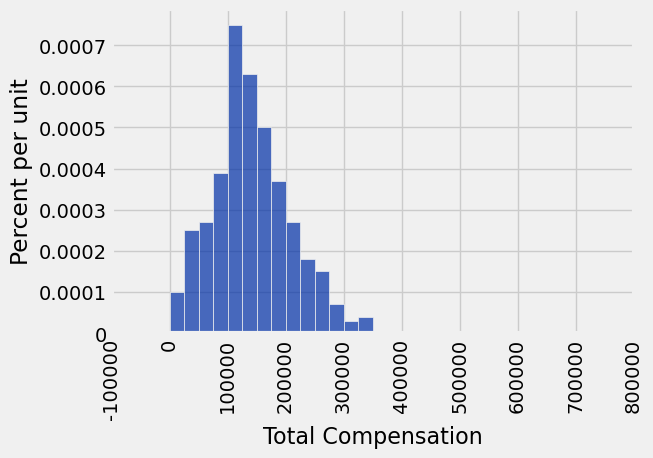

In [24]:
# Display a histogram of your sample data using the sf_bins.

our_sample.hist('Total Compensation', bins=sf_bins)


In [26]:
#Find the median of your sample. 

percentile(50, our_sample.column('Total Compensation') )

#How close is it to the population parameter?
#How close was your neighbor's value to the parameter?

133830.0

But in the real world we won't be able to keep going back to the population. 
Why?

We need to know how to generate a new random sample *without going back to the population.*

# Bootstrap

Creating a sample from an existing sample.

Sample randomly
 - from the original sample
 - with replacement (allows for repeats of the same record)
 - the same number of times as the original sample size

### Example Bootstrap

In [27]:
#start with a "data set"

original = make_array(1,2,3,4,5)
original

array([1, 2, 3, 4, 5])

In [29]:
#Use existing "data set" to create a new "data set"
# Create a table
table = Table().with_columns('Original', original)

# Add an array as a new column
new_column = table.sample()
table.with_columns(
    'Bootstrap 1', new_column.column(0)
)

Original,Bootstrap 1
1,3
2,2
3,4
4,1
5,3


In [30]:
#Use a loop to add four new bootstraps
for i in np.arange(1,5):
    new_column = table.sample()
    table = table.with_columns(
            f'Bootstrap {i}', new_column.column(0)
    )
table

Original,Bootstrap 1,Bootstrap 2,Bootstrap 3,Bootstrap 4
1,5,5,5,5
2,4,4,2,5
3,5,3,1,4
4,4,4,2,1
5,5,4,2,1


In [31]:
# Default behavior of tbl.sample:
# at random with replacement,
# the same number of times as rows of tbl

bootstrap_sample = our_sample.sample()


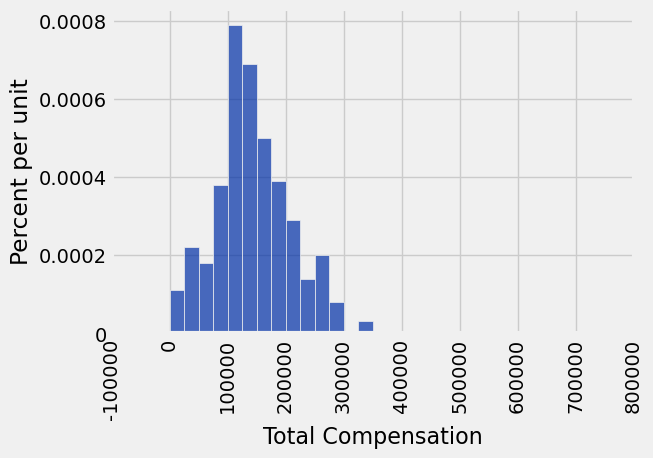

In [33]:
# Create a histogram of the bootstrap samples using the sf_bins.

bootstrap_sample.hist('Total Compensation', bins=sf_bins)

## Bootstrap Sample Median
This is one estimate of the population median.

In [34]:
# Find the median income from the bootstrap sample

percentile(50, bootstrap_sample.column('Total Compensation') )

138088.0

In [35]:
#Create a function that finds a bootstrap sample, then returns the median of that sample.

def one_bootstrap_median():
    
    # draw the bootstrap sample
    resample = our_sample.sample()
    
    # return the median total compensation in the bootstrap sample
    return percentile(50, resample.column('Total Compensation'))

In [36]:
# Test the function

one_bootstrap_median()


136418.0

In [37]:
# Generate the medians of 1000 bootstrap samples

num_repetitions = 1000

bstrap_medians = make_array()

for i in np.arange(num_repetitions):
    bstrap_medians = np.append(bstrap_medians, one_bootstrap_median())
    

In [38]:
# Create a table that stores the medians under the column Bootstrap Sample Median

resampled_medians = Table().with_column('Bootstrap Sample Median', bstrap_medians)


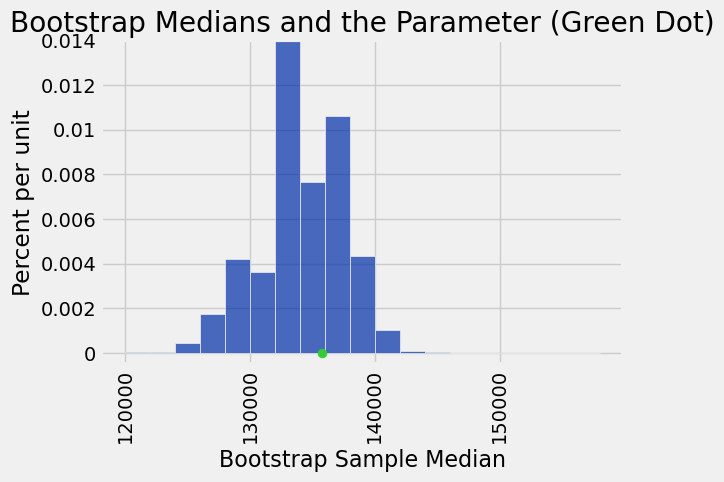

In [40]:
median_bins=np.arange(120000, 160000, 2000)

#Display a histogram of the resampled medians using the given bins. 
resampled_medians.hist(bins = median_bins)


# Plotting the original parameter; do not change. 
parameter_green = '#32CD32'
plots.ylim(-0.000005, 0.00014)
plots.scatter(pop_median, 0, color=parameter_green, s=40, zorder=2)
plots.title('Bootstrap Medians and the Parameter (Green Dot)');

## Percentile Method: Middle 95% of the Bootstrap Estimates

This is called a Confidence Interval. 

We can say we are 95% confident, that if we repeat this study many times, the population parameter will be captured in 95% of the generated intervals. </br>
We are not 95% confident that our interval contains the population parameter. 

95% of our data is between two values, what are those values?

In [41]:
#There is 5% left over in tails. 

#How much is in the lower tail?
left = percentile(2.5, bstrap_medians)

#To find the upper value we add the lower tail + the 95%.
right = percentile(97.5, bstrap_medians)

#Display those values.
make_array(left, right)

array([ 127468.,  139937.])

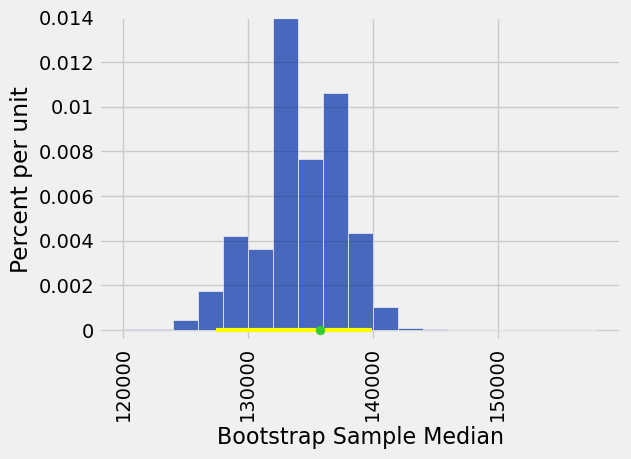

In [42]:
resampled_medians.hist(bins = median_bins)

# Plotting parameters and the 95%, do not change.
plots.ylim(-0.000005, 0.00014)
plots.plot(make_array(left, right), make_array(0, 0), color='yellow', lw=3, zorder=1)
plots.scatter(pop_median, 0, color=parameter_green, s=40, zorder=2);

***Did the Bootstrap Method give a good estimate to the population parameter?***

## Interpreting a confidence interval: ##

We are <u><em>some</em>%</u> confident that the true <u><em>description of the statistic with the group studied and what study is about</em></u> is between <u><em>low value</em></u> and <u><em>high value</em></u>.

Use this structure to interpret our confidence interval. 